In [2]:
import pandas
pandas.set_option('display.max_columns', None)

df = pandas.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")

df.drop(columns=['PassengerId', 'Name' , 'Ticket' , 'Cabin'], inplace=True)
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


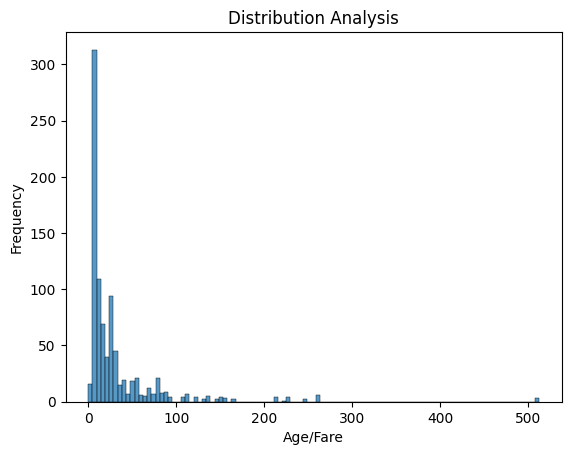

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Fare'])
# sns.histplot(df['Sex'])

# Add titles and labels
plt.title('Distribution Analysis')
plt.xlabel('Age/Fare')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [ ]:
df.isnull().sum()

In [4]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline

In [21]:
transformer1 = ColumnTransformer([
    ('si_Age' , SimpleImputer(strategy='mean') , ['Age']),
    ('si_Embarked' , SimpleImputer(strategy='most_frequent') , ['Embarked'])
], remainder='passthrough')

transformer1.set_output(transform="pandas")
x= transformer1.fit_transform(df) #After the application of this tranformer this is returning a numpy array rather than a pandas dataframe

print(type(x))
print(x.shape)
print(transformer1.get_feature_names_out()) #Hey transformer1, you gave me this NumPy array. What are the names of the features/columns corresponding to its positions?

<class 'pandas.core.frame.DataFrame'>
(891, 8)
['si_Age__Age' 'si_Embarked__Embarked' 'remainder__Survived'
 'remainder__Pclass' 'remainder__Sex' 'remainder__SibSp'
 'remainder__Parch' 'remainder__Fare']


In [23]:
transformer2 = ColumnTransformer([
    ('ohe_Sex' , OneHotEncoder(sparse_output=False, drop='first') , ['remainder__Sex']),
    ('ohe_Embarked' , OneHotEncoder(sparse_output=False, drop='first') , ['si_Embarked__Embarked'])
], remainder='passthrough') #Now this increases the number of columns in the df and also change the column name

transformer2.set_output(transform="pandas")
y = transformer2.fit_transform(x)

print(type(y))
print(y.shape)
print(transformer2.get_feature_names_out())

<class 'pandas.core.frame.DataFrame'>
(891, 9)
['ohe_Sex__remainder__Sex_male' 'ohe_Embarked__si_Embarked__Embarked_Q'
 'ohe_Embarked__si_Embarked__Embarked_S' 'remainder__si_Age__Age'
 'remainder__remainder__Survived' 'remainder__remainder__Pclass'
 'remainder__remainder__SibSp' 'remainder__remainder__Parch'
 'remainder__remainder__Fare']


In [24]:
#Now what to choose b/w MixMaxScaler and Standarization[Here the data Age is bounded from 0 to 100 mostly so here we use MinMaxScaling]
#After ploting a Histplot its much clear that the MInMaxScaler is a better choice
transformer3 = ColumnTransformer([
    ('mm_Age' , MinMaxScaler() , ['remainder__si_Age__Age']),
    ('ss_scaler' , StandardScaler() , ['remainder__remainder__Fare']) #Fare contains extreme outliers then we must use StandardScaler
], remainder='passthrough')

z = transformer3.set_output(transform="pandas")
z = transformer3.fit_transform(y)

print(type(z))
print(z.shape)
print(transformer3.get_feature_names_out())


<class 'pandas.core.frame.DataFrame'>
(891, 9)
['mm_Age__remainder__si_Age__Age' 'ss_scaler__remainder__remainder__Fare'
 'remainder__ohe_Sex__remainder__Sex_male'
 'remainder__ohe_Embarked__si_Embarked__Embarked_Q'
 'remainder__ohe_Embarked__si_Embarked__Embarked_S'
 'remainder__remainder__remainder__Survived'
 'remainder__remainder__remainder__Pclass'
 'remainder__remainder__remainder__SibSp'
 'remainder__remainder__remainder__Parch']


In [28]:
pipe = Pipeline([
    ('transformer1' , transformer1),
    ('transformer2' , transformer2),
    ('transformer3' , transformer3)
])

xyz = pipe.fit_transform(df)

xyz.head()

,mm_Age__remainder__si_Age__Age,ss_scaler__remainder__remainder__Fare,remainder__ohe_Sex__remainder__Sex_male,remainder__ohe_Embarked__si_Embarked__Embarked_Q,remainder__ohe_Embarked__si_Embarked__Embarked_S,remainder__remainder__remainder__Survived,remainder__remainder__remainder__Pclass,remainder__remainder__remainder__SibSp,remainder__remainder__remainder__Parch
0,0.271174,-0.502445,1.0,0.0,1.0,0,3,1,0
1,0.472229,0.786845,0.0,0.0,0.0,1,1,1,0
2,0.321438,-0.488854,0.0,0.0,1.0,1,3,0,0
3,0.434531,0.420730,0.0,0.0,1.0,1,1,1,0
4,0.434531,-0.486337,1.0,0.0,1.0,0,3,0,0
